# Finally, lets do some orientation estimation...

Rotation is a **super** important aspect of Aerospace as well as Spaceshot. We care a TON about how the rocket is oriented for the overall safety and tilt angle of the rocket. This is especially important for our *two stage* rockets in which we have a safety precaution where if our rocket is currently oriented pointing sideways or down in flight, to NOT ignite the second motor. Thus, our attitude estimation algorithms are super important for our rocket safety! 

**Last time you learned about quaternions which is the language of orientation.** We will now extend this language to implement a orientation estimation algorithm called the **Multiplicative Extended Kalman Filter (MEKF).** The MEKF is super simple if you understand the Kalman Filter! If you have forgotten how a Kalman Filter works I encourage you to review it in the Kalman filter module. Otherwise I will assume you have a basis on the Kalman filter...we will just now be changing translation estimation to orientation estimation! 

### What is this "Multiplicative" business about?

In standard Kalman filters, we update state by simple vector addition: $x_{i} = x_{i-1} + \Delta x$. But quaternions live on a unit sphere, meaning a valid orientation quaternion **must** have a norm of 1 ($||q|| = 1$). If you simply add a 4D object $\delta q$ to $q$, the result is no longer a unit quaternion! Thus, we instead use **multiplication** here. To update a quaternion, 

$${\mathbf{q}_{i}} = {\mathbf{q}_{i-1}} + \frac{1}{2} \boldsymbol{\Omega} \otimes \mathbf{q}_{i-1}$$

such that $\Omega$ is the quaternion represented by the angular velocity, $\mathbf{\Omega} = (0,\omega_x,\omega_y,\omega_z)$. 

When we are speaking about translation in the EKF, our state vector consists of position and velocities. Instead, the MEKF separates orientation into:
1. A full **reference unit quaternion** $\hat{q}$ (representing orientation).
2. A 3D **small error-angle vector** $\delta \theta = [\delta \phi, \delta \theta, \delta \psi]^T$ (representing small tilt/error angles) from where we think we are. 

We approximate small error angles as a quaternion:

$$\delta q \approx \begin{bmatrix} 1 \\ \frac{1}{2} \delta \theta \end{bmatrix}$$

And apply corrections **multiplicatively**:

$$\hat{q}_{new} = \hat{q} \otimes \delta q$$

**Our goal in the MEKF is to take a predefined known reference quaternion and throughout flight estimate these corrections. From there we apply them to the reference quaternion over time. Thus, providing us with a quaternion estimate of orientation.**

Our 6D Kalman error state vector is:

$$\delta x = \begin{bmatrix} \delta \theta \\ \delta b \end{bmatrix} = \begin{bmatrix} \delta \theta_x \\ \delta \theta_y \\ \delta \theta_z \\ \delta b_x \\ \delta b_y \\ \delta b_z \end{bmatrix} \in \mathbb{R}^6$$

where $\delta \theta$ is small orientation error and $\delta b$ is gyroscope bias error. Gyroscope bias error is another thing that is important. Gyroscopes are known to drift overtime....this takes this into account and also estimates how biased the gyroscope is within a point of time in flight! 

### Some supplmentation: The Skew-Symmetric Operator

Vector cross products $v \times w$ happen everywhere in 3D rotation. Thus, I will define it here.  We express the cross product as a matrix multiplication using the **skew-symmetric matrix** $[v \times]$:

$$[v \times] = \begin{bmatrix} 0 & -v_z & v_y \\ v_z & 0 & -v_x \\ -v_y & v_x & 0 \end{bmatrix}$$

such that $[v \times] w = v \times w$. So whenever you see $[v \times]$ understand this is what that means. 

### Your Turn: Skew-Symmetric Matrix Helper

Let's write a helper function `skew(v)` that takes a 3-element vector $v = [v_x, v_y, v_z]$ and returns its $3 \times 3$ skew-symmetric matrix.

In [ ]:
#% exercise
#% checker: check_ex1
import numpy as np
import quaternion as qt

### BEGIN STUB
def skew(v):
    # Return the 3x3 skew-symmetric matrix of vector v
    return None
### END STUB
### BEGIN SOLUTION
def skew(v):
    return np.array([
        [0.0, -v[2], v[1]],
        [v[2], 0.0, -v[0]],
        [-v[1], v[0], 0.0]
    ])
### END SOLUTION

v_test = np.array([1.0, 2.0, 3.0])
print("skew(v_test):\n", skew(v_test))


# Okay lets start with the first step of each filter...The Predict Step (Gyro Propagation)

A 3-axis gyroscope measures angular rate $\omega_m$, which includes true rate $\omega$, gyro bias $b$, and noise $\eta_{gyro}$:

$$\omega_m = \omega + b + \eta_{gyro}$$

Our corrected angular velocity estimate is:

$$\hat{\omega} = \omega_m - \hat{b}$$

**Quaternion Propagation forward in dt:**
Quaternion orientation propagates over time step $dt$. This is the same as propagating our dynamics in a Kalman Filter. 

$$\hat{q}_{k} =  \hat{q}_{k-1} + \frac{1}{2} \Omega \otimes \hat{q}_{k-1} \cdot dt$$

such that $\Omega$ is the quaternion represented by the angular velocity, $\mathbf{\Omega} = (0,\omega_x,\omega_y,\omega_z)$. 

We now renormalize our quaternion to ensure unit size quaternions,

$$\hat{q}_{k} = normalized(\hat{q}_{k})$$

**We now propogate our covariance...**
The 6x6 state transition matrix $\Phi$ is:

$$\Phi = \begin{bmatrix} I_{3\times 3} - [\hat{\omega} \times] dt & -I_{3\times 3} dt \\ 0_{3 \times 3} & I_{3\times 3} \end{bmatrix}$$

And discrete process noise covariance $Q_d$ is:

$$Q_d = \begin{bmatrix} \sigma_{gyro}^2 dt \cdot I_{3\times 3} & 0_{3 \times 3} \\ 0_{3 \times 3} & \sigma_{bias}^2 dt \cdot I_{3\times 3} \end{bmatrix}$$

The covariance matrix $P$ propagates as:

$$P_{k|k-1} = \Phi P_{k-1|k-1} \Phi^T + Q_d$$

### Your Turn - State Prediction 

Implement `predict_state(estimate, b_hat, P, measured_omega, dt, sigma_gyro, sigma_bias)`. Return `(estimate_next, P_next, Phi)`.

In [53]:
#% exercise
#% checker: check_ex2
import numpy as np
import quaternion as qt

### BEGIN STUB
def predict_state(estimate, b_hat, P, measured_omega, dt, sigma_gyro, sigma_bias):
    # 1. Correct angular velocity: omega_hat = measured_omega - b_hat
    # 2. Update quaternion estimate and normalize
    # 3. Build 6x6 state transition matrix Phi
    # 4. Build 6x6 process noise covariance Q_d
    # 5. Propagate P_next = Phi @ P @ Phi.T + Q_d
    return estimate, P, np.eye(6)
### END STUB
### BEGIN SOLUTION
def predict_state(estimate, b_hat, P, measured_omega, dt, sigma_gyro, sigma_bias):
    omega_hat = measured_omega - b_hat

    estimate_next = (estimate + 0.5 * qt.quaternion(0, *omega_hat) * estimate * dt).normalized()

    Phi = np.eye(6)
    Phi[0:3, 0:3] = np.eye(3) - skew(omega_hat) * dt
    Phi[0:3, 3:6] = -np.eye(3) * dt
    Phi[3:6, 3:6] = np.eye(3)

    Q_d = np.eye(6)
    Q_d[0:3, 0:3] *= dt * (sigma_gyro**2)
    Q_d[3:6, 3:6] *= dt * (sigma_bias**2)

    P_next = Phi @ P @ Phi.T + Q_d
    return estimate_next, P_next, Phi
### END SOLUTION


### The Update Step (Accelerometer Measurement)

Gyroscopes drift over time when integrating angular rates! We use an **accelerometer** measuring gravity to correct attitude drift.

When non-gravitational acceleration is small, the accelerometer measures reference gravity $g_{ref} = [0, 0, -9.81]^T$ rotated into the body frame:

$$\hat{a} = R(\hat{q})^T g_{ref}$$

The bigger picture of what we are doing here is taking a reference gravity in the intertial $g_{ref}$ and comparing that to what is measured in the body frame $\hat{a}$ (recall that this will be the same vector just in two different frames) and attempting to find the transformation $(R(\hat{q})^T)$ between them. 

**Similar to the EKF, we compute the measurement jacobian $H$ (3x6):**
The 3x6 Jacobian relating vector measurement to error state $[\delta \theta, \delta b]^T$ is:

$$H = \begin{bmatrix} -[\hat{a} \times] & 0_{3 \times 3} \end{bmatrix}$$

**From there its just the standard EKF equations, innovation & Kalman Gain:**
- Residual: $r = a_{meas} - \hat{a}$
- Innovation Covariance: $S = H P H^T + R$
- Kalman Gain: $K = P H^T S^{-1}$
- Error state correction: $\delta x = K r = [\delta \theta^T, \delta b^T]^T$

**and then apply corrections just now in the rotational form:**
- Multiplicative orientation update: $\hat{q} \leftarrow (\hat{q} \otimes \text{quaternion}(1, \frac{1}{2} \delta \theta)).\text{normalized}()$
- Gyro bias update: $\hat{b} \leftarrow \hat{b} + \delta b$
- Covariance update: $P \leftarrow (I - K H) P (I - K H)^T + K R K^T$

### Your Turn - MEKF Update Step

Implement `update_state(estimate, b_hat, P, measured_accel, g_ref, R)`. Return `(estimate_updated, b_hat_updated, P_updated)`.

In [ ]:
#% exercise
#% checker: check_ex3
import numpy as np
import quaternion as qt

### BEGIN STUB
def update_state(estimate, b_hat, P, measured_accel, g_ref, R):
    # 1. Compute predicted accel vector: a_hat = R(estimate).T @ g_ref
    # 2. Build 3x6 Jacobian H = [-skew(a_hat), 0_3x3]
    # 3. Compute Kalman Gain K = P @ H.T @ inv(H @ P @ H.T + R)
    # 4. Compute residual r = measured_accel - a_hat and dx = K @ r
    # 5. Multiplicatively update estimate and additively update b_hat
    # 6. Update covariance matrix P
    return estimate, b_hat, P
### END STUB
### BEGIN SOLUTION
def update_state(estimate, b_hat, P, measured_accel, g_ref, R):
    R_body_to_inertial = qt.as_rotation_matrix(estimate)
    a_hat = R_body_to_inertial.T @ g_ref

    H = np.zeros((3, 6))
    H[0:3, 0:3] = -skew(a_hat)

    S = H @ P @ H.T + R
    K = P @ H.T @ np.linalg.inv(S)

    r = measured_accel - a_hat
    dx = K @ r
    delta_theta = dx[0:3]
    delta_b = dx[3:6]

    delta_q = qt.quaternion(1.0, *(0.5 * delta_theta))
    estimate_updated = (estimate * delta_q).normalized()
    b_hat_updated = b_hat + delta_b

    I6 = np.eye(6)
    P_updated = (I6 - K @ H) @ P @ (I6 - K @ H).T + K @ R @ K.T
    return estimate_updated, b_hat_updated, P_updated
### END SOLUTION


### Bringing It All Together: The Complete MEKF

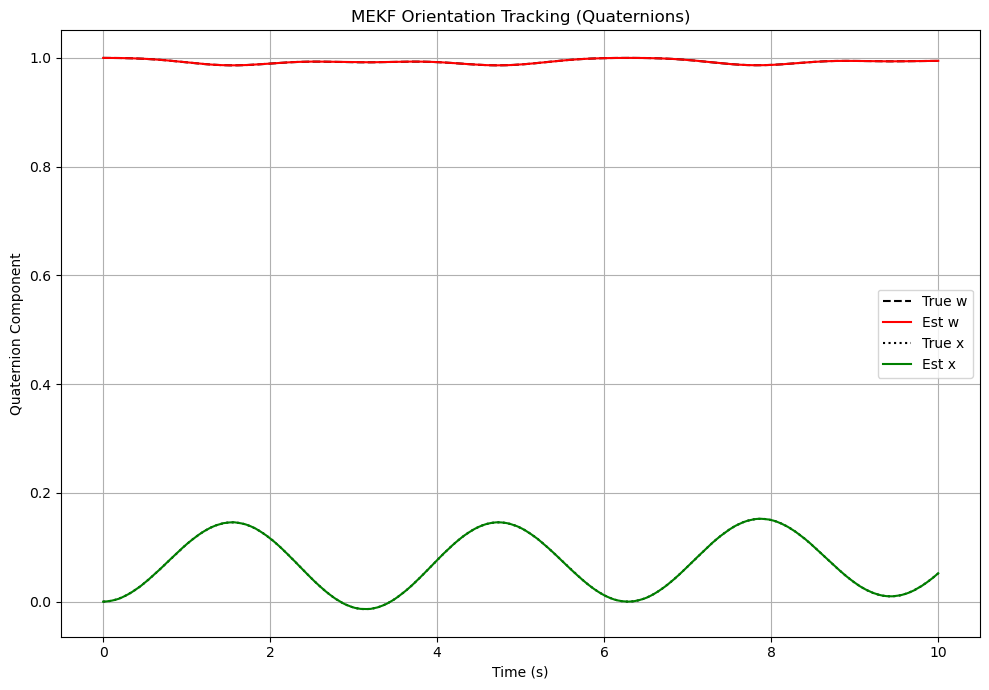

In [52]:
import numpy as np
import quaternion as qt
import matplotlib.pyplot as plt

class MEKF:
    def __init__(self, dt_ms=5.0):
        self.dt = dt_ms / 1000.0  # Time step in seconds
        self.estimate = qt.quaternion(1.0, 0.0, 0.0, 0.0)  # Initial orientation
        self.b_hat = np.array([0.0, 0.0, 0.0])  # Estimated gyro bias
        self.a_hat = np.array([0.0, 0.0, 0.0])  # Estimated accel vector
        
        self.sigma_gyro = 0.002#0.02  # gyro noise rad/s
        self.sigma_bias = 1e-10#1e-5  # bias random walk
        sigma_acc = 0.003# 0.03        # accel noise m/s^2
        
        self.P = np.eye(6)
        self.P[0:3, 0:3] *= (self.sigma_gyro**2)
        self.P[3:6, 3:6] *= (self.sigma_bias**2)
        
        self.R = np.eye(3) * (sigma_acc**2)
        self.g_ref = np.array([0.0, 0.0, -9.81])  # reference gravity (Z-down)

    def skew(self, v):
        return np.array([
            [0.0, -v[2], v[1]],
            [v[2], 0.0, -v[0]],
            [-v[1], v[0], 0.0]
        ])

    def predict_state(self, measured_omega):
        omega_hat = measured_omega - self.b_hat
        self.estimate = (self.estimate + 0.5 * qt.quaternion(0, *omega_hat) * self.estimate * self.dt).normalized()
        Phi = np.eye(6)
        Phi[0:3, 0:3] = np.eye(3) - self.skew(omega_hat) * self.dt
        Phi[0:3, 3:6] = -np.eye(3) * self.dt
        Phi[3:6, 3:6] = np.eye(3)

        Q_d = np.eye(6)
        Q_d[0:3, 0:3] *= self.dt * (self.sigma_gyro**2)
        Q_d[3:6, 3:6] *= self.dt * (self.sigma_bias**2)

        self.P = Phi @ self.P @ Phi.T + Q_d

    def update_state(self, measured_accel):
        R_body_to_inertial = qt.as_rotation_matrix(self.estimate)
        self.a_hat = R_body_to_inertial.T @ self.g_ref

        H = np.zeros((3, 6))
        H[0:3, 0:3] = self.skew(self.a_hat)

        S = H @ self.P @ H.T + self.R
        K = self.P @ H.T @ np.linalg.inv(S)

        r = measured_accel - self.a_hat
        dx = K @ r
        delta_theta = dx[0:3]
        delta_b = dx[3:6]

        delta_q = qt.quaternion(1.0, *(0.5 * delta_theta))
        self.estimate = (self.estimate * delta_q).normalized()
        self.b_hat += delta_b

        I6 = np.eye(6)
        self.P = (I6 - K @ H) @ self.P @ (I6 - K @ H).T + K @ self.R @ K.T

# Run Simulation
dt_ms = 10.0
dt = dt_ms / 1000.0
total_time = 10.0
steps = int(total_time / dt)

true_bias = np.array([0,0,0]) 
true_q = qt.quaternion(1.0, 0.0, 0.0, 0.0)
mekf = MEKF(dt_ms=dt_ms)

q_est_history, q_true_history, b_hat_history = [], [], []

for k in range(steps):
    t = k * dt
    w_true = np.array([0.3 * np.sin(2 * t), 0.2 * np.cos(1.5 * t), 0.1 * np.sin(t)])
    true_q = (true_q + 0.5 * qt.quaternion(0, *w_true) * true_q * dt).normalized()
    
    measured_omega = w_true + true_bias + np.random.normal(0, 0.002, 3)
    R_true = qt.as_rotation_matrix(true_q)
    measured_accel = R_true.T @ mekf.g_ref + np.random.normal(0, 0.003, 3)
    
    mekf.predict_state(measured_omega)
    mekf.update_state(measured_accel)
    
    q_est_history.append([mekf.estimate.w, mekf.estimate.x, mekf.estimate.y, mekf.estimate.z])
    q_true_history.append([true_q.w, true_q.x, true_q.y, true_q.z])
    b_hat_history.append(mekf.b_hat.copy())

q_est_history = np.array(q_est_history)
q_true_history = np.array(q_true_history)
b_hat_history = np.array(b_hat_history)
time_vec = np.linspace(0, total_time, steps)

fig, axs = plt.subplots( figsize=(10, 7))
axs.plot(time_vec, q_true_history[:, 0], 'k--', label='True w')
axs.plot(time_vec, q_est_history[:, 0], 'r', label='Est w')
axs.plot(time_vec, q_true_history[:, 1], 'k:', label='True x')
axs.plot(time_vec, q_est_history[:, 1], 'g', label='Est x')
axs.set_title('MEKF Orientation Tracking (Quaternions)')
axs.set_xlabel('Time (s)')
axs.set_ylabel('Quaternion Component')
axs.legend()
axs.grid(True)


plt.tight_layout()
plt.show()
